The paper “COVID-19 Public Sentiment Insights and Machine Learning for Tweets Classification” investigates public emotional responses to the COVID-19 pandemic by analyzing Twitter data. The study addresses the spread of fear and misinformation—termed the "infodemic"—and aims to better understand how fear sentiment evolved as the pandemic unfolded in the U.S.

Researchers collected tweets related to Coronavirus using Twitter’s API and conducted sentiment analysis to detect emotional tones, with a strong focus on fear. Using R and standard text analytics libraries, they visualized sentiment trends over time through tools like word clouds and sentiment progression graphs.

In addition to descriptive analysis, the paper compares two classic machine learning classifiers: Naive Bayes and Logistic Regression. Tweets were labeled as fear, neutral, or positive, and the models were trained to classify them accordingly. Results showed that Naive Bayes performed best on short tweets, achieving 91% accuracy, while Logistic Regression reached 74%. However, both models performed worse on longer tweets.

While the study doesn't propose new algorithms, it offers valuable insight into how basic ML techniques can be used for real-time sentiment classification during a global crisis. The authors suggest these methods can support public health messaging and policy decisions. Limitations include a relatively small dataset and the absence of modern NLP models like transformers.

pip install pandas numpy matplotlib seaborn nltk scikit-learn transformers torch accelerate

In [4]:
# if You don't have nltk please install it!!
# pip install pandas nltk scikit-learn

import pandas as pd
import nltk
import re
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score

# 1. 필수 리소스 다운로드
nltk.download('stopwords')
nltk.download('punkt')

# 2. 데이터 불러오기
try:
    # 동일 폴더 내의 파일을 읽어옵니다.
    df = pd.read_csv('dataset_A_news_full_10500.csv')
    print("데이터 로드 완료! 총 데이터 수:", len(df))
except FileNotFoundError:
    print("파일을 찾을 수 없습니다. 파일명을 확인해주세요.")

# 3. 텍스트 전처리 함수
def preprocess_text(text):
    # 소문자 변환 및 특수문자 제거
    text = re.sub(r'[^a-zA-Z\s]', '', str(text).lower())
    # 불용어(Stopwords) 제거
    stop_words = set(stopwords.words('english'))
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

# 뉴스 제목 전처리 적용
df['clean_title'] = df['title'].apply(preprocess_text)

# 4. 데이터셋 분리 (X: 뉴스 제목, y: 카테고리)
X = df['clean_title']
y = df['classes_str']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. 텍스트 벡터화 (TF-IDF 방식)
# 단어의 빈도와 중요도를 고려하여 숫자로 변환합니다.
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# 6. 모델 생성 및 학습 (Multinomial Naive Bayes)
model = MultinomialNB()
model.fit(X_train_tfidf, y_train)

# 7. 결과 예측 및 평가
y_pred = model.predict(X_test_tfidf)

print("\n--- 분석 결과 ---")
print(f"전체 정확도(Accuracy): {accuracy_score(y_test, y_pred):.2f}")
print("\n[클래스별 상세 리포트]")
print(classification_report(y_test, y_pred))

# 8. (추가) 새로운 제목으로 테스트해보기
def predict_category(new_title):
    processed = preprocess_text(new_title)
    vectorized = tfidf.transform([processed])
    prediction = model.predict(vectorized)
    return prediction[0]

# 예시 테스트
sample_title = "New AI model breakthrough in healthcare"
print(f"\n테스트 제목: {sample_title}")
print(f"예측된 클래스: {predict_category(sample_title)}")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\zxcvz\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\zxcvz\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


데이터 로드 완료! 총 데이터 수: 10500

--- 분석 결과 ---
전체 정확도(Accuracy): 0.46

[클래스별 상세 리포트]
                                                                                                                                                                                                    precision    recall  f1-score   support

                                                                                                                                                                       Cognitive & Decision-Making       0.85      0.43      0.57        76
                                                                                                                                    Cognitive & Decision-Making; Creativity, Expression & Identity       0.00      0.00      0.00         1
                                                                                                   Cognitive & Decision-Making; Creativity, Expression & Identity; Learning, Knowledge & Education       0.00      0

C:\Users\zxcvz\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\zxcvz\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\zxcvz\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

Map:   0%|          | 0/5310 [00:00<?, ? examples/s]

Map:   0%|          | 0/1328 [00:00<?, ? examples/s]

Generating predictions for the validation set...


C:\Users\zxcvz\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


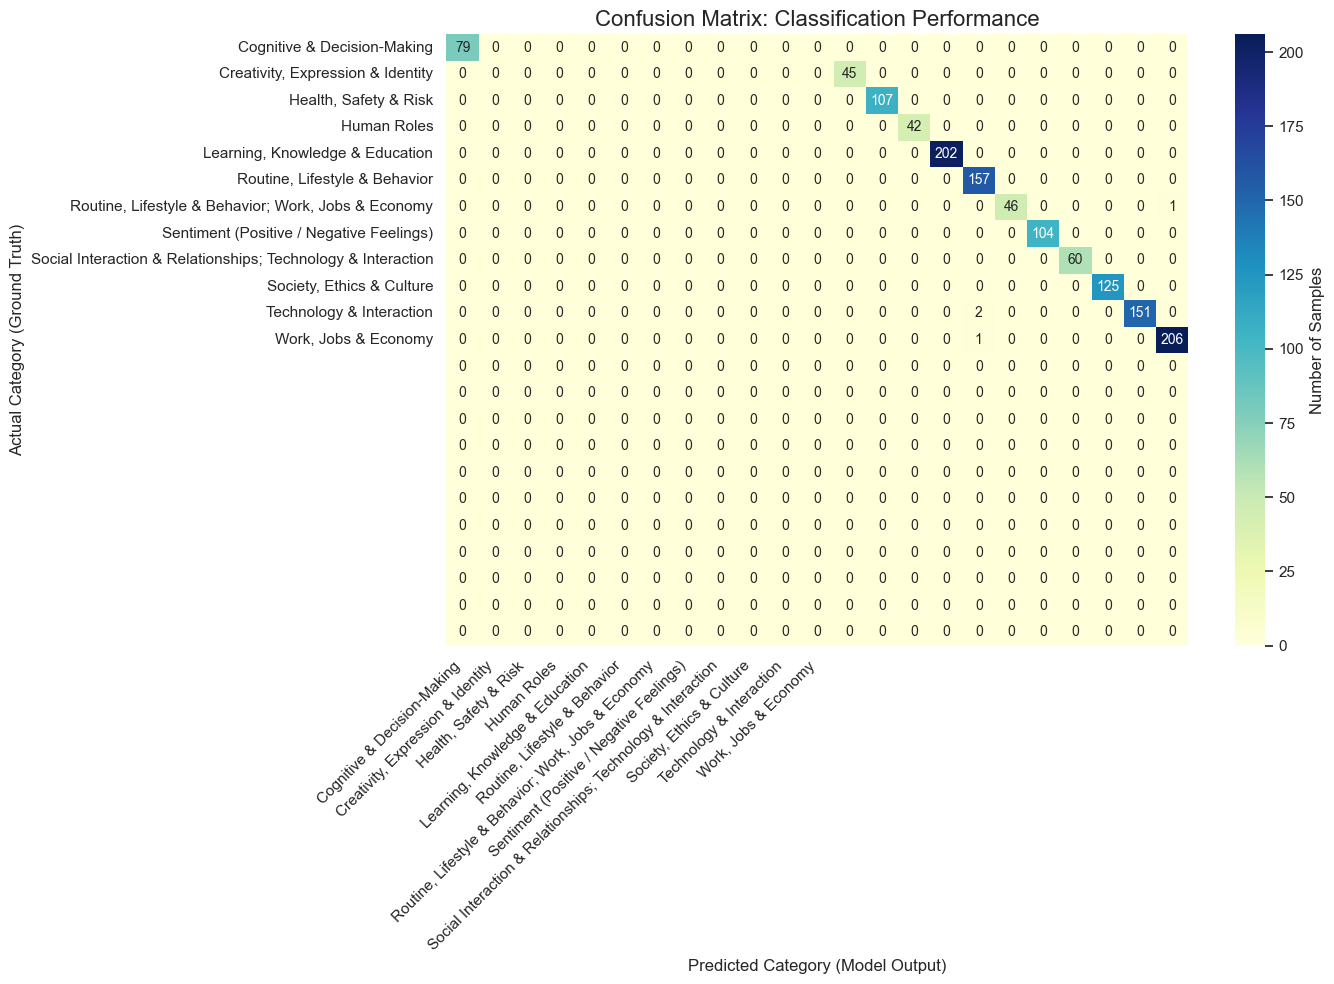


TOP 5 CLASSIFICATION ERRORS (Frequent Confusions)


In [3]:
# =============================
# 1) 필수 라이브러리 로딩
# =============================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import torch
import joblib

from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
from transformers import (
    AutoTokenizer, 
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)
from datasets import Dataset

# =============================
# 2) 데이터 로딩 + 전처리
# =============================
df = pd.read_csv("dataset_A_news_full_10500.csv")

# 상위 12개 class만 학습에 사용
top_classes = df["classes_str"].value_counts().head(12).index
df = df[df["classes_str"].isin(top_classes)].reset_index(drop=True)

# LabelEncoder (문자열 → 숫자)
le = LabelEncoder()
df["label"] = le.fit_transform(df["classes_str"].astype(str))

# 텍스트/레이블 리스트
texts = df["title"].astype(str).tolist()
labels = df["label"].tolist()

# =============================
# 3) HuggingFace Dataset
# =============================
# 입력 텍스트 + 레이블로 Dataset 생성
dataset = Dataset.from_dict({
    "text": texts,
    "label": labels
})

# train/validation 분리
split = dataset.train_test_split(test_size=0.2, seed=42)
train_dataset = split["train"]
val_dataset   = split["test"]

val_labels = val_dataset["label"]
class_names = le.classes_

# 토크나이저 로딩
model_path = "./my_bert_model"
tokenizer = AutoTokenizer.from_pretrained(model_path)

# 토크나이즈 함수
def tokenize_batch(batch):
    return tokenizer(batch["text"], padding="max_length", truncation=True, max_length=128)

train_dataset = train_dataset.map(tokenize_batch, batched=True)
val_dataset   = val_dataset.map(tokenize_batch, batched=True)

# Trainer가 input_ids/attention_mask/labels를 알 수 있게 rename
train_dataset = train_dataset.rename_column("label", "labels")
val_dataset   = val_dataset.rename_column("label", "labels")

train_dataset.set_format(type="torch", columns=["input_ids","attention_mask","labels"])
val_dataset.set_format(type="torch", columns=["input_ids","attention_mask","labels"])

# =============================
# 4) 모델 로딩
# =============================
model = AutoModelForSequenceClassification.from_pretrained(model_path)

# =============================
# 5) 평가 지표
# =============================
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc}

# =============================
# 6) Trainer 정의
# =============================
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_dir='./logs',
    fp16=torch.cuda.is_available(),
    load_best_model_at_end=True,
    metric_for_best_model="accuracy"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

# =============================
# 7) Validation Set 예측
# =============================
print("Generating predictions for the validation set...")
output = trainer.predict(val_dataset)
preds = np.argmax(output.predictions, axis=-1)

# =============================
# 8) Confusion Matrix 그리기
# =============================
cm = confusion_matrix(val_labels, preds)

plt.figure(figsize=(14, 10))
sns.set_theme(style="white")

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='YlGnBu',
    xticklabels=class_names,
    yticklabels=class_names,
    cbar_kws={'label': 'Number of Samples'},
    annot_kws={"size": 10}
)

plt.title('Confusion Matrix: Classification Performance', fontsize=16)
plt.ylabel('Actual Category (Ground Truth)', fontsize=12)
plt.xlabel('Predicted Category (Model Output)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# =============================
# 9) Top 5 Frequent Errors
# =============================
print("\n" + "="*50)
print("TOP 5 CLASSIFICATION ERRORS (Frequent Confusions)")
print("="*50)

mask = np.ones(cm.shape, dtype=bool)
np.fill_diagonal(mask, 0)
errors = cm * mask

top_error_indices = np.unravel_index(np.argsort(errors.ravel())[-5:][::-1], errors.shape)

for i in range(5):
    actual_idx = top_error_indices[0][i]
    pred_idx   = top_error_indices[1][i]
    count      = errors[actual_idx, pred_idx]
    
    actual_name = class_names[actual_idx]


In [4]:
import pandas as pd
import torch
import numpy as np
import joblib
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from torch.utils.data import Dataset

# 1. Data load & preprocessing
df = pd.read_csv('dataset_A_news_full_10500.csv')

# Encode text labels into numbers
le = LabelEncoder()
df['label'] = le.fit_transform(df['classes_str'])
num_labels = len(le.classes_)

# CRITICAL: Save the LabelEncoder for deployment
# This allows your friends to convert predicted numbers back to category names
joblib.dump(le, "label_encoder.pkl")

# 2. Prepare tokenizer and dataset
model_name = "distilbert-base-uncased" # Lightweight and efficient for personal PCs
tokenizer = AutoTokenizer.from_pretrained(model_name)

class NewsDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels
    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item
    def __len__(self):
        return len(self.labels)

# Split data (80% Training, 20% Validation)
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['title'].astype(str).tolist(), df['label'].tolist(), test_size=0.2, random_state=42
)

# Tokenize text data
train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=64)
val_encodings = tokenizer(val_texts, truncation=True, padding=True, max_length=64)

train_dataset = NewsDataset(train_encodings, train_labels)
val_dataset = NewsDataset(val_encodings, val_labels)

# 3. Set model and define accuracy calculation
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_labels)

# This function calculates Accuracy (%) during the evaluation phase
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {"accuracy": accuracy_score(labels, predictions)}

# 4. Training Arguments (Optimized for low RAM and high performance)
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=4,   # Reduced batch size to prevent "Out of Memory"
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=4,  # Actual training batch size is 16 (4*4)
    eval_strategy="epoch",          # Updated syntax from 'evaluation_strategy'
    save_strategy="epoch",
    logging_dir='./logs',
    fp16=torch.cuda.is_available(), # Use Mixed Precision for faster training if GPU is available
    load_best_model_at_end=True,    # Automatically load the most accurate model at the end
    metric_for_best_model="accuracy"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics  # Added to track Accuracy (%)
)

# 5. Start Training
print("Start training... This may take about 30-40 minutes.")
trainer.train()

# 6. Save the trained model for your friends
# These files are necessary for sharing/deploying the project
save_path = "./my_bert_model"
trainer.save_model(save_path)
tokenizer.save_pretrained(save_path)
print(f"Model saved to {save_path}")

# 7. Final Evaluation
results = trainer.evaluate()
print("\n--- Final Analysis Results ---")
print(f"Validation Accuracy: {results['eval_accuracy'] * 100:.2f}%")

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
C:\Users\zxcvz\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Start training... This may take about 30-40 minutes.


Epoch,Training Loss,Validation Loss,Accuracy
1,3.036500,1.612214,0.724286
2,1.195900,1.023550,0.816667
3,0.794000,0.891542,0.847619


C:\Users\zxcvz\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
C:\Users\zxcvz\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Model saved to ./my_bert_model


C:\Users\zxcvz\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)



--- Final Analysis Results ---
Validation Accuracy: 84.76%


In [5]:
import joblib
import torch
from transformers import pipeline

# 1. Load the LabelEncoder (Converts numbers to actual names)
# Make sure 'label_encoder.pkl' is in the same folder
le = joblib.load("label_encoder.pkl")

# 2. Load the trained model using the 'pipeline' API
# 'device=-1' means use CPU. Change to 0 if they have a GPU.
model_path = "./my_bert_model"
classifier = pipeline("text-classification", model=model_path, tokenizer=model_path, device=0)

def predict_news_category(title):
    """
    Function to predict category from a news title
    """
    # Get raw prediction (e.g., {'label': 'LABEL_5', 'score': 0.98})
    result = classifier(title)[0]
    
    # Extract the numeric index from the label string (e.g., 'LABEL_5' -> 5)
    label_idx = int(result['label'].split('_')[-1])
    
    # Convert index to the original class name
    category_name = le.inverse_transform([label_idx])[0]
    confidence = result['score'] * 100
    
    return category_name, confidence

# --- TEST AREA ---
test_title = "New AI technology improves medical diagnosis accuracy"
category, score = predict_news_category(test_title)

print(f"News Title: {test_title}")
print(f"Predicted Category: {category}")
print(f"Confidence Score: {score:.2f}%")

Device set to use cpu


News Title: New AI technology improves medical diagnosis accuracy
Predicted Category: Health, Safety & Risk; Technology & Interaction
Confidence Score: 34.03%


In [6]:
# Updated function to show Top 3 predictions
def predict_top_k(title, k=3):
    # Get all probabilities
    results = classifier(title, top_k=k)
    
    print(f"\n[Input Title]: {title}")
    print("-" * 30)
    
    for i, res in enumerate(results):
        # Extract index and convert to name
        label_idx = int(res['label'].split('_')[-1])
        category_name = le.inverse_transform([label_idx])[0]
        score = res['score'] * 100
        
        print(f"Top {i+1}: {category_name} ({score:.2f}%)")

# Example usage for your teammates
predict_top_k("New AI technology improves medical diagnosis accuracy")


[Input Title]: New AI technology improves medical diagnosis accuracy
------------------------------
Top 1: Health, Safety & Risk; Technology & Interaction (34.03%)
Top 2: Routine, Lifestyle & Behavior; Technology & Interaction (8.02%)
Top 3: Technology & Interaction (7.70%)


Model output size: 392
TARGET_LABELS length: 392


C:\Users\zxcvz\AppData\Local\Temp\ipykernel_22504\1712810328.py:82: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dfC_long[f"p_{label}"] = probs_C[:, idx]
C:\Users\zxcvz\AppData\Local\Temp\ipykernel_22504\1712810328.py:82: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dfC_long[f"p_{label}"] = probs_C[:, idx]
C:\Users\zxcvz\AppData\Local\Temp\ipykernel_22504\1712810328.py:82: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider 

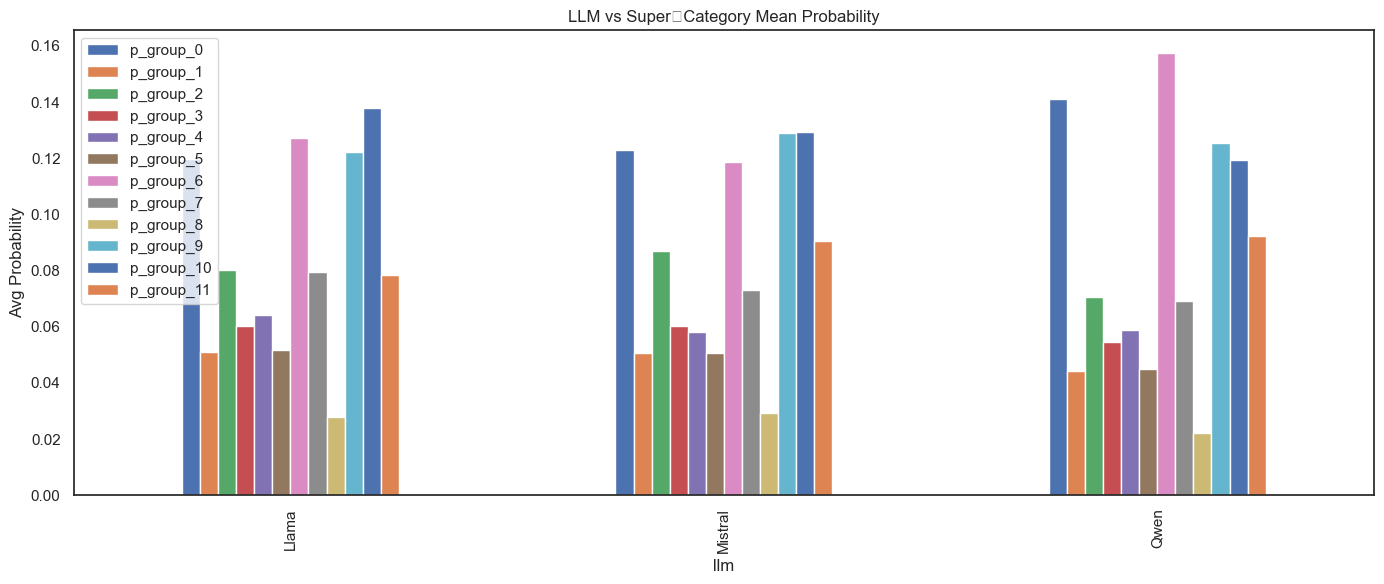

C:\Users\zxcvz\AppData\Local\Temp\ipykernel_22504\1712810328.py:123: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\zxcvz\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


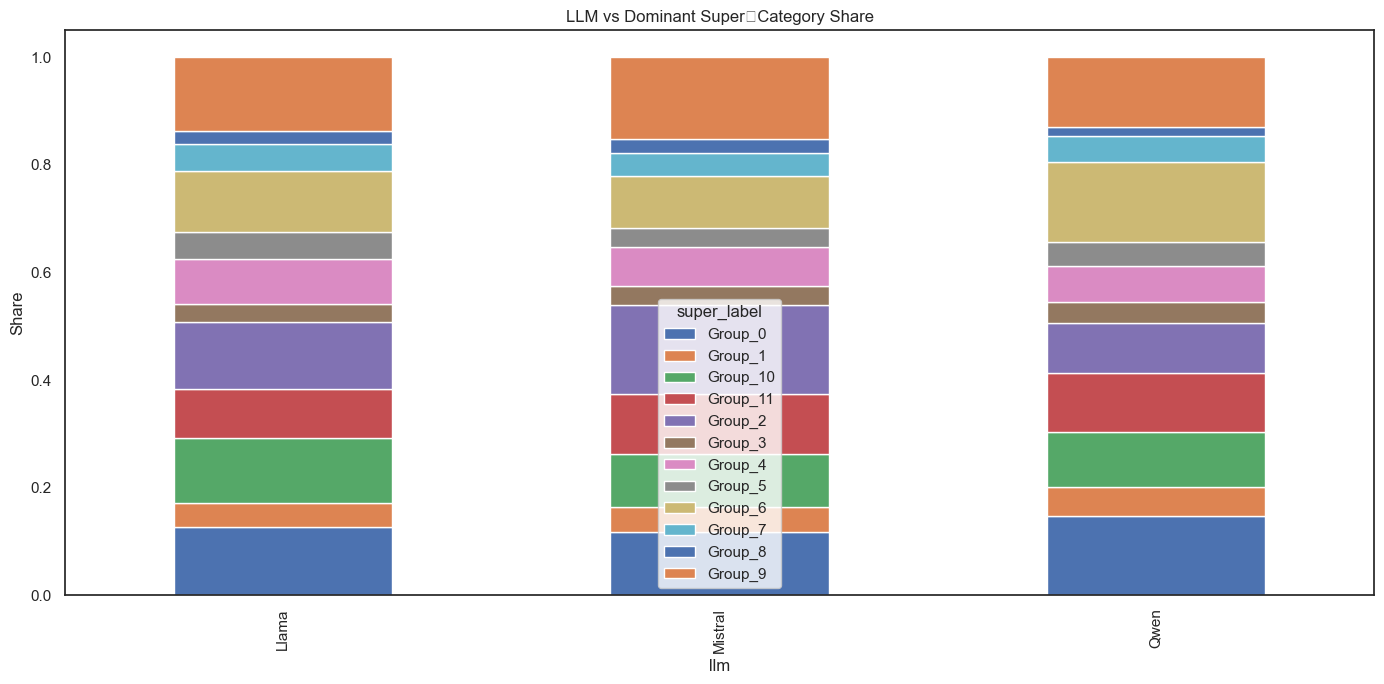

C:\Users\zxcvz\AppData\Local\Temp\ipykernel_22504\1712810328.py:129: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dfC_long["persona_short"] = dfC_long["prompt"].map(


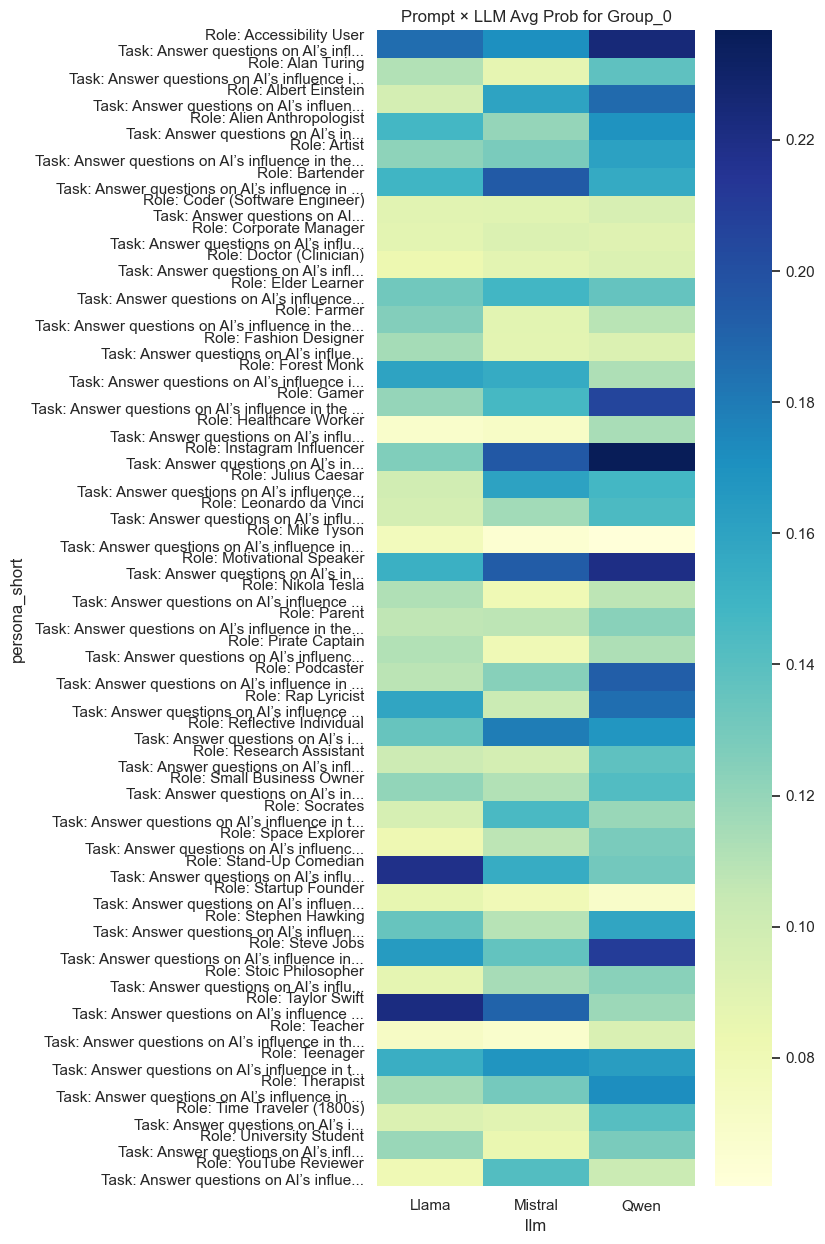

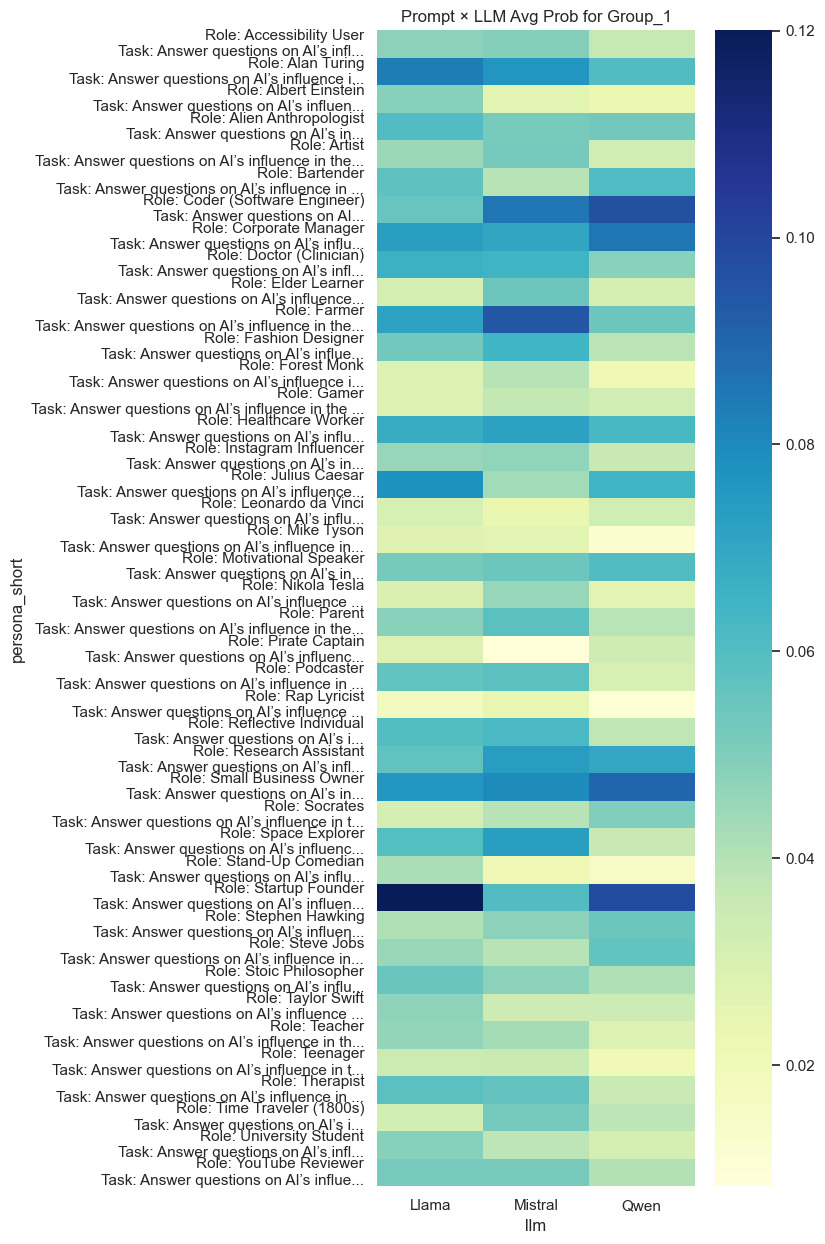

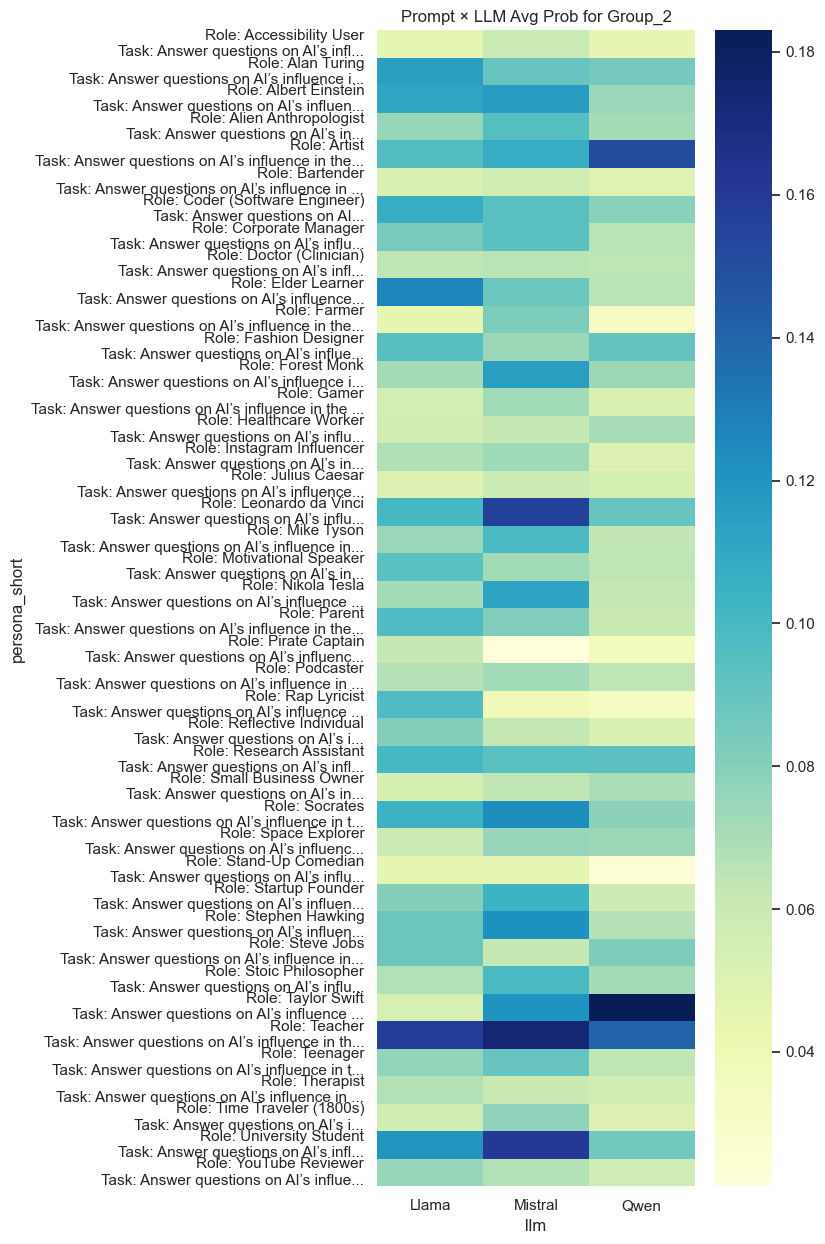

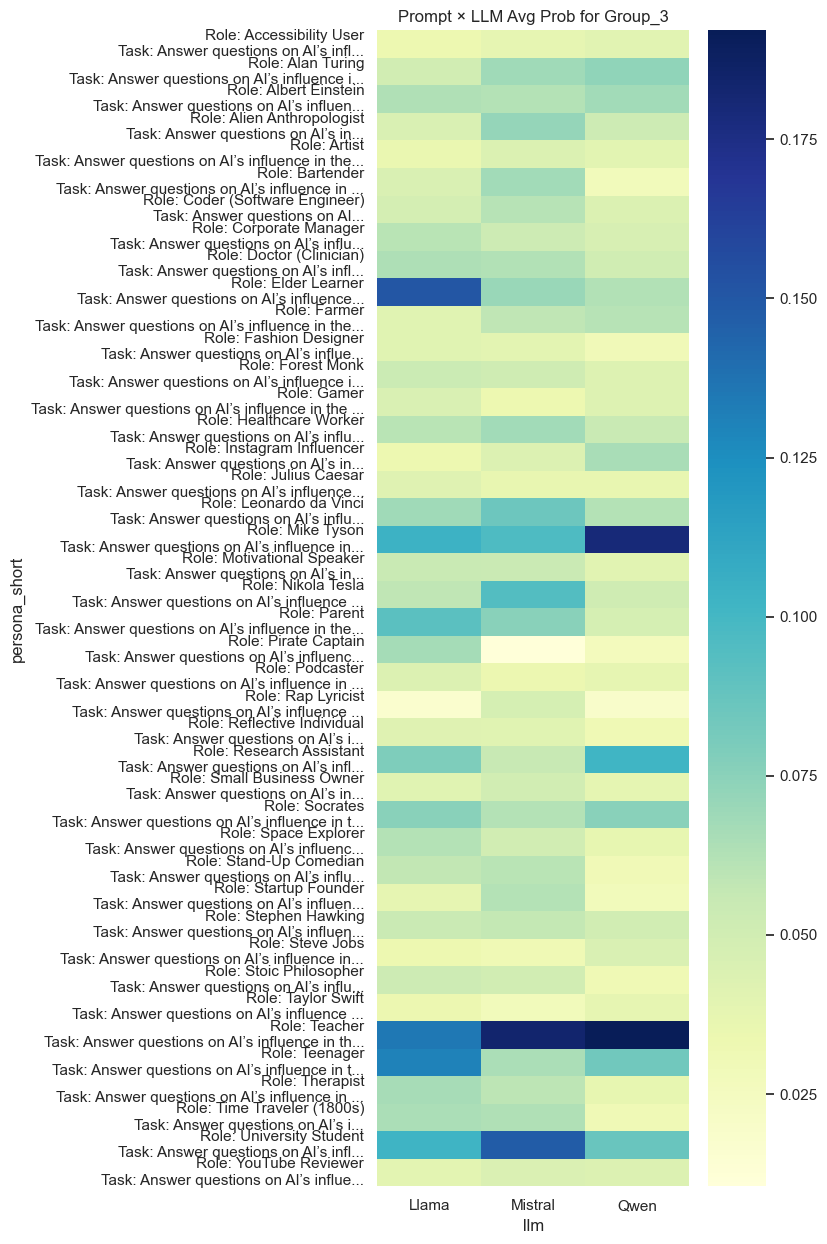

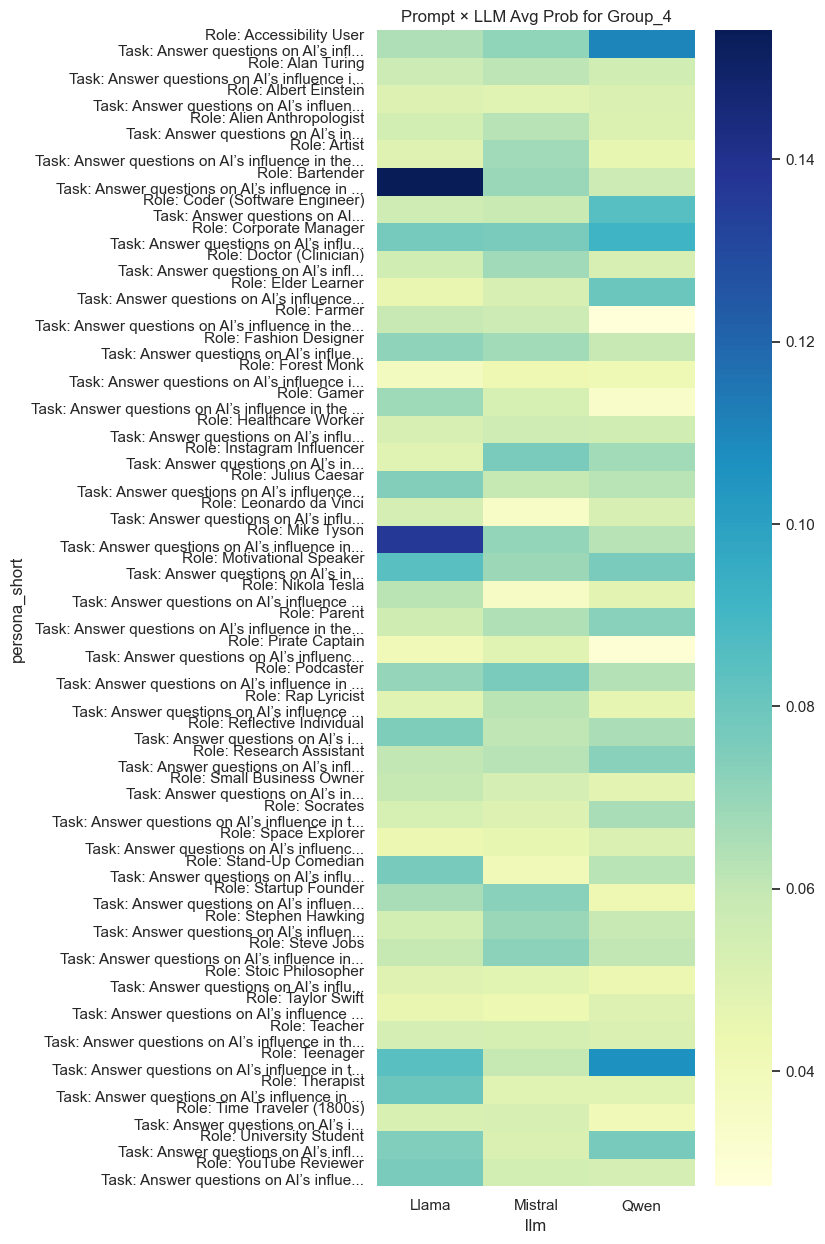

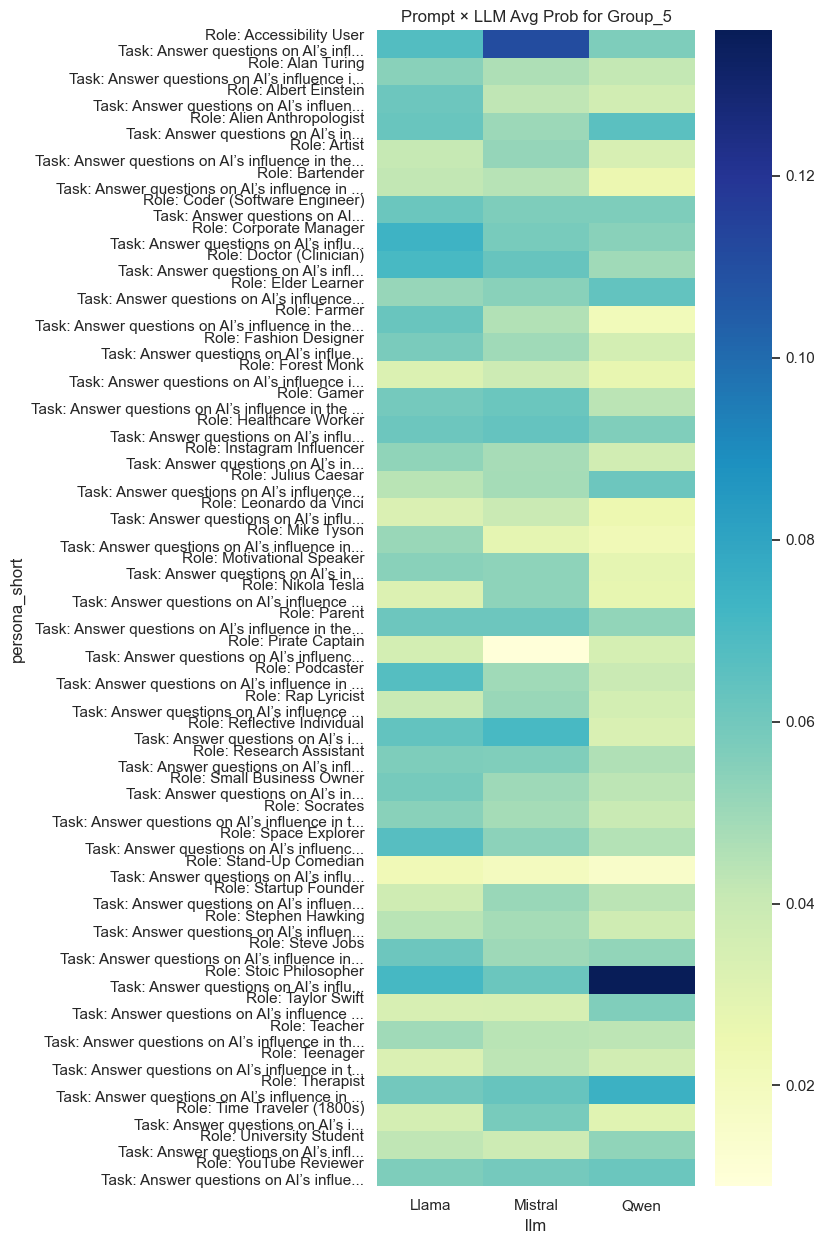

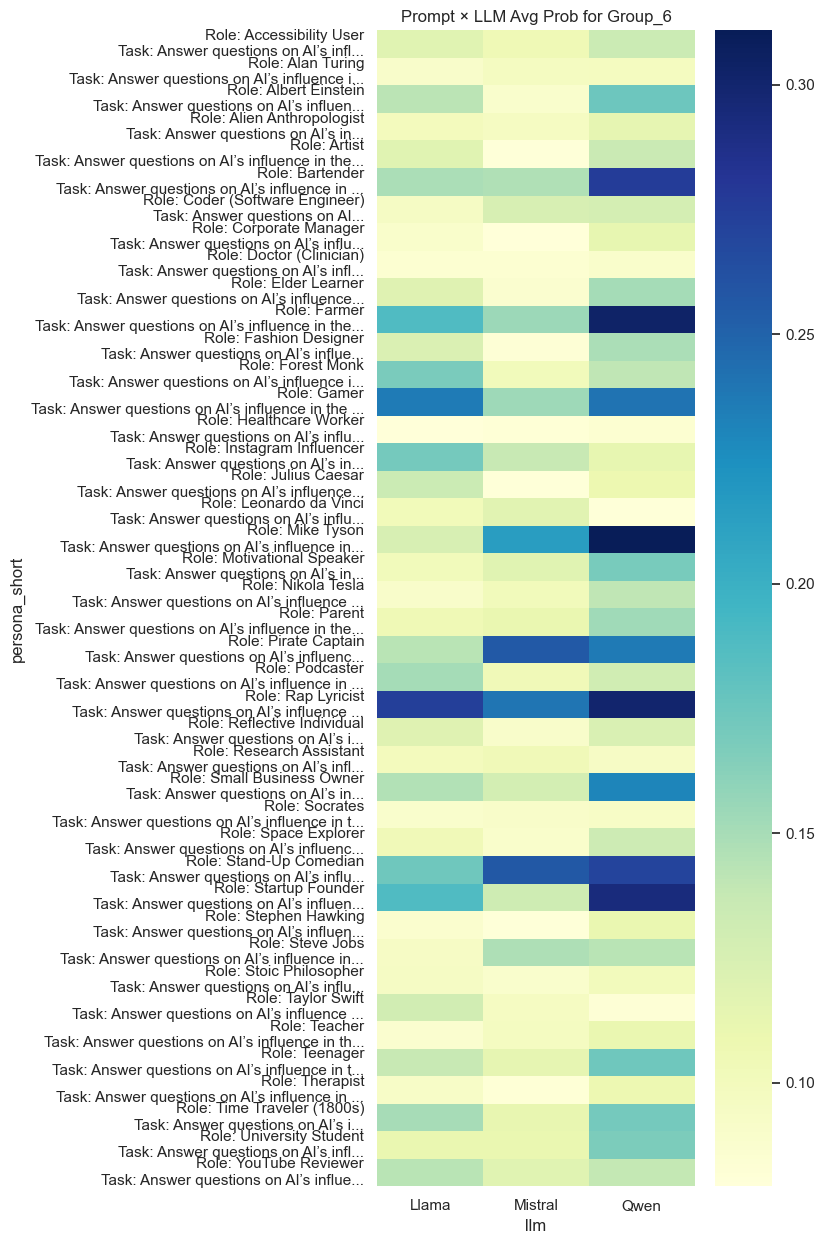

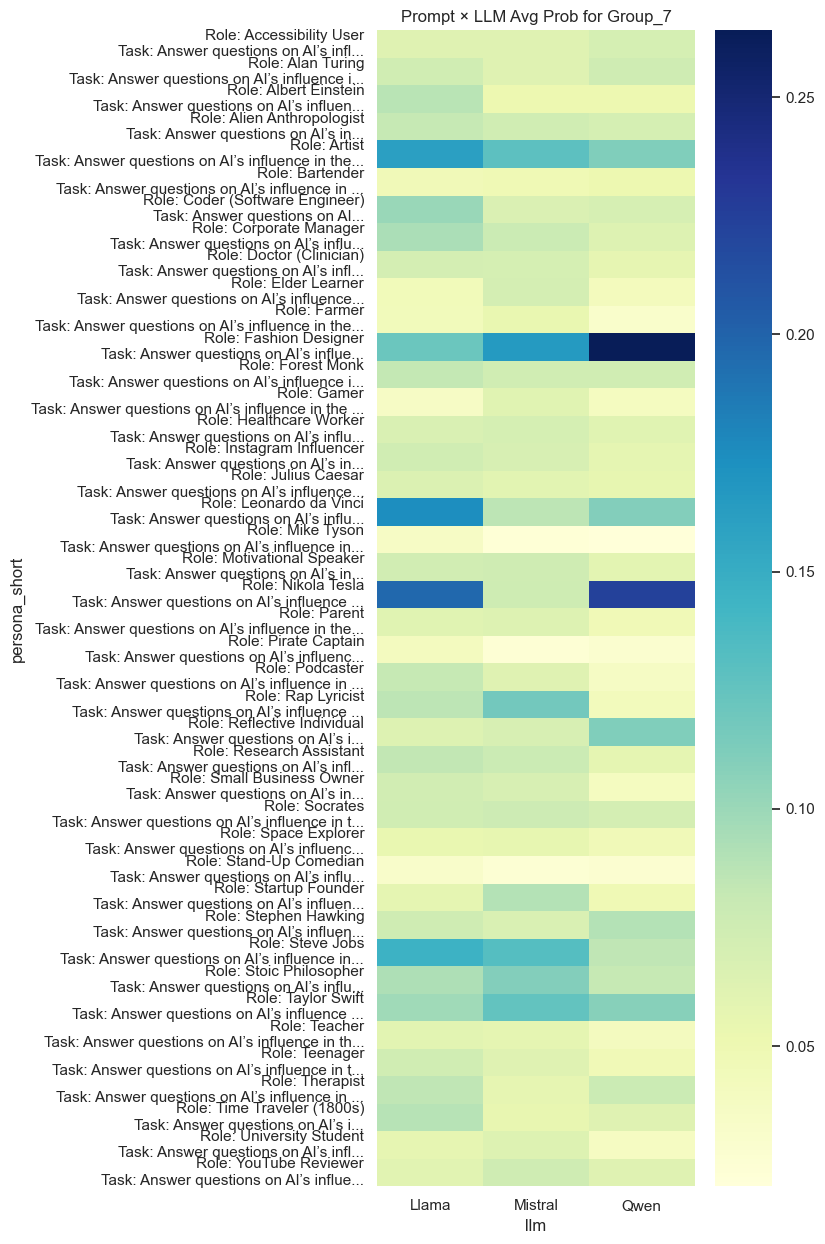

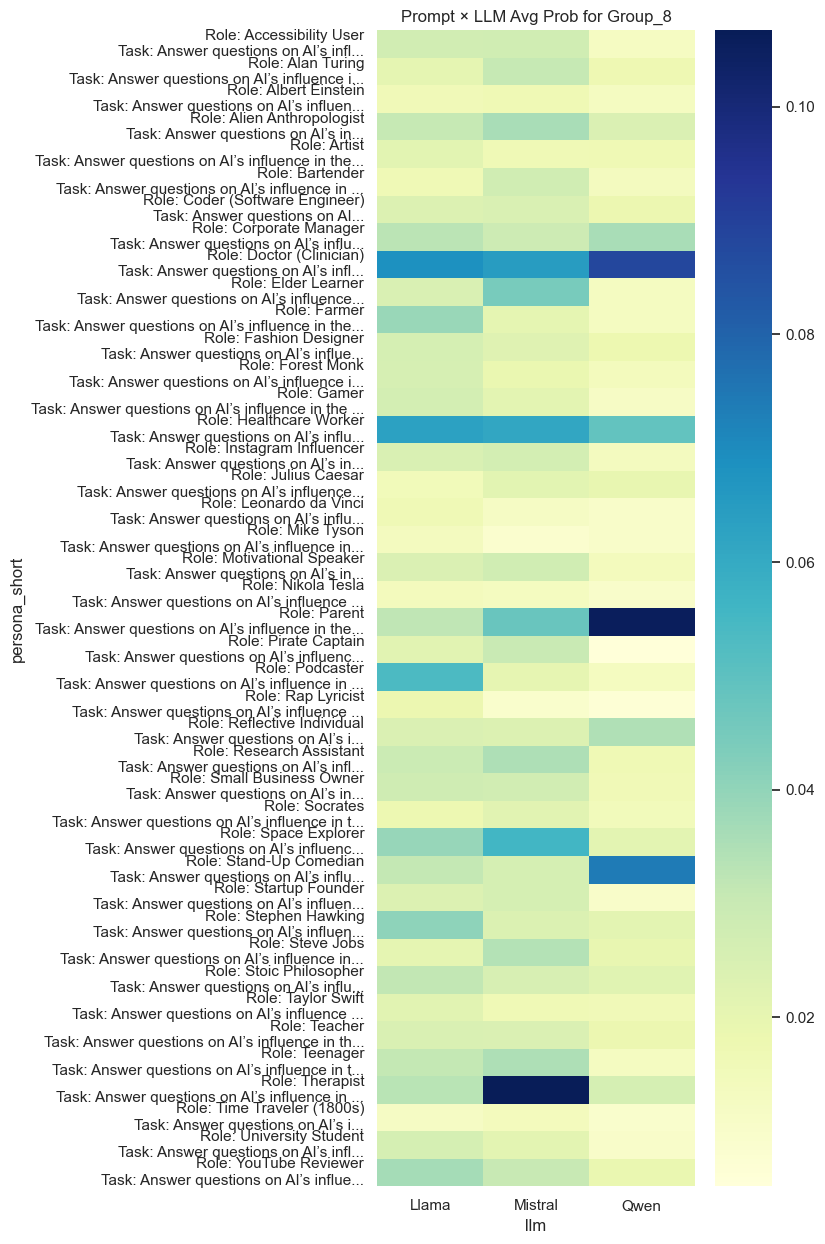

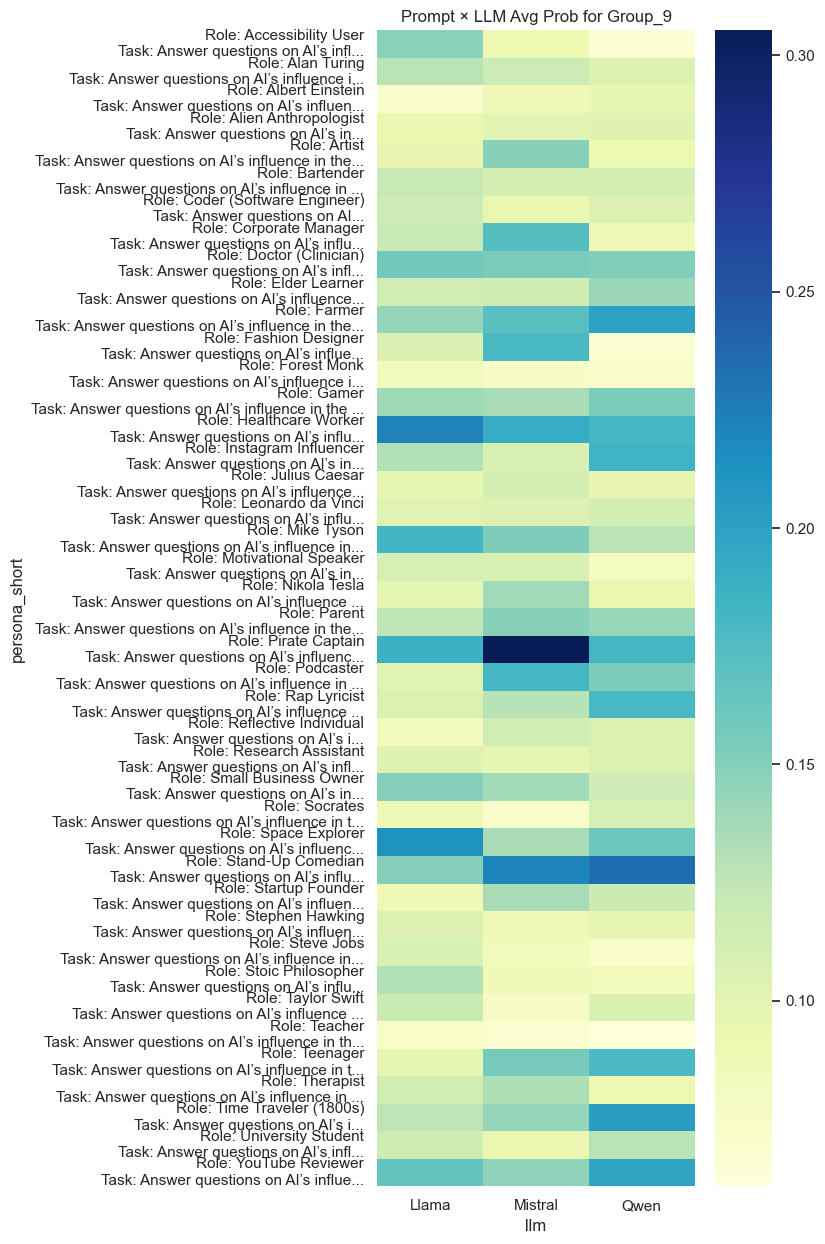

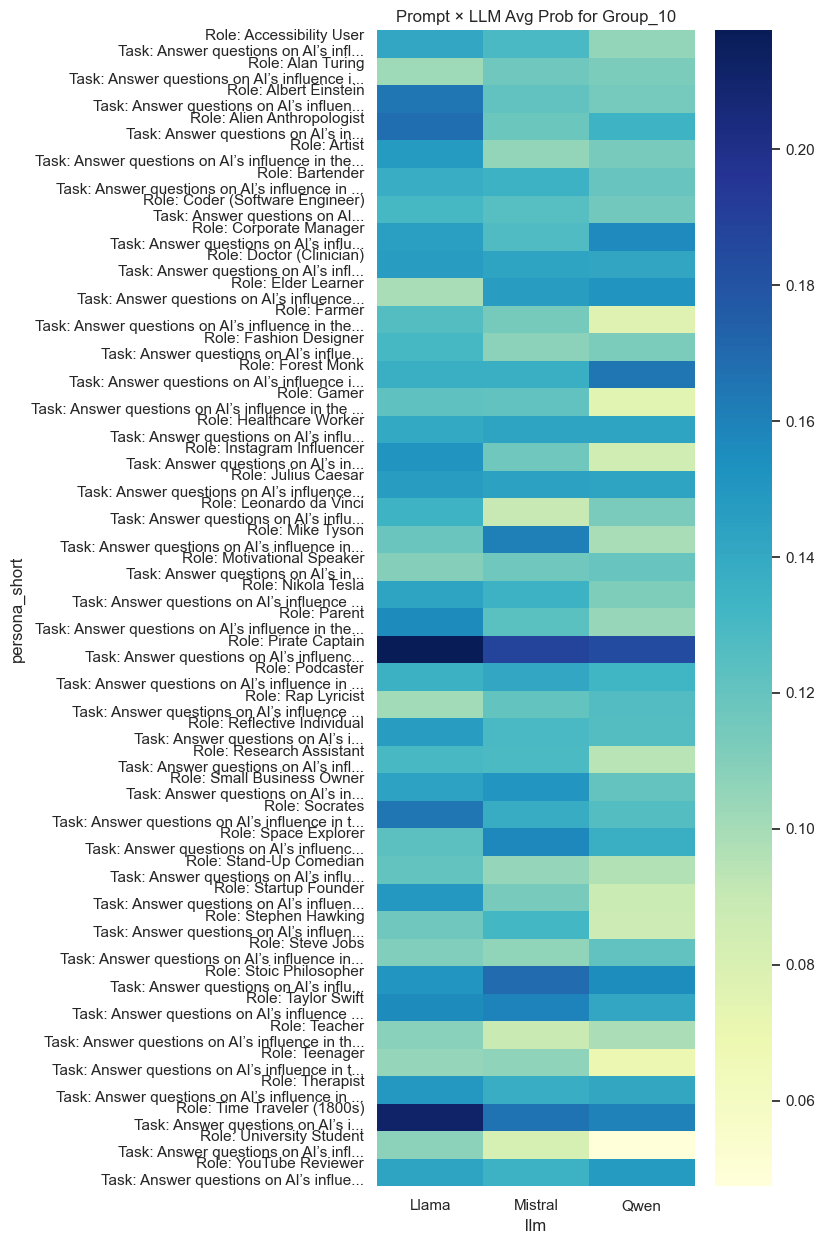

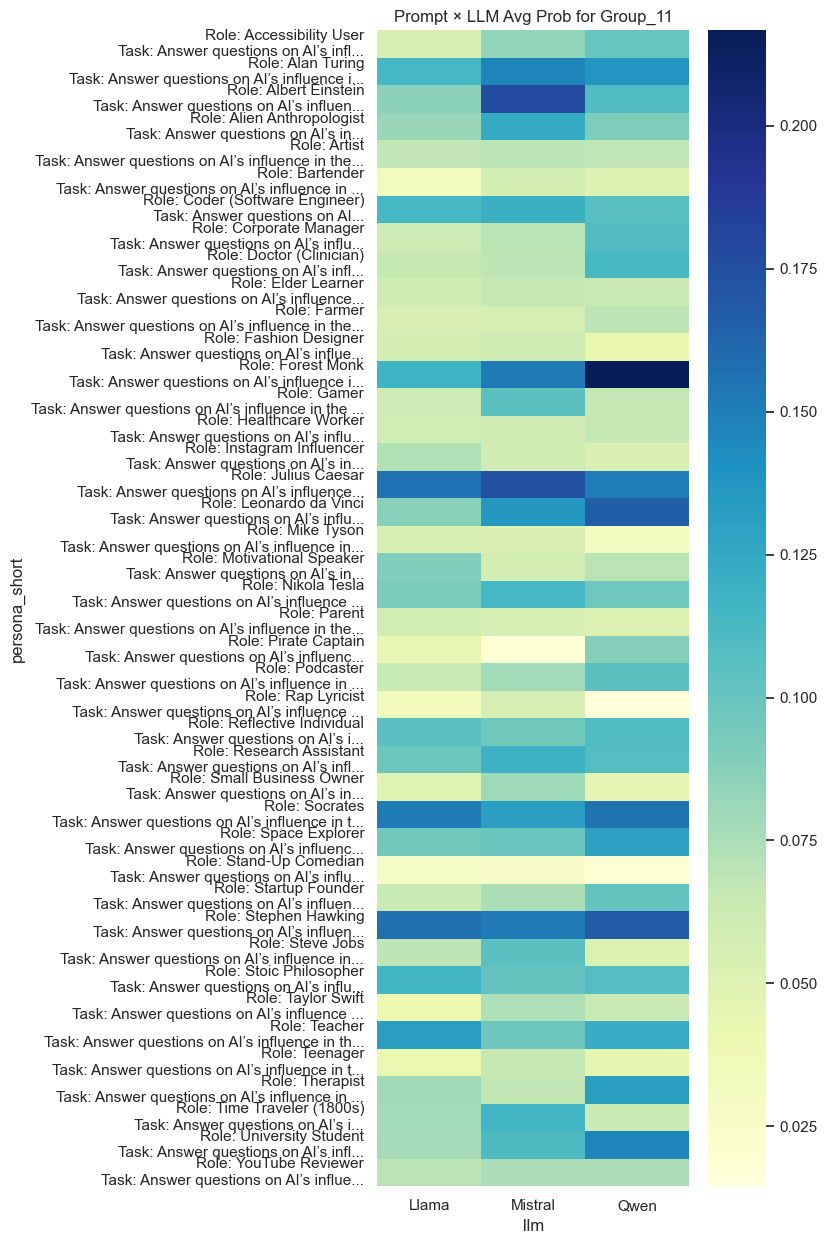

In [18]:
#### Starting new code with DatasetC ####

# ==============================================
#  (1) Dataset C 전처리
# ==============================================
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ✅ DEVICE 정의
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ✅ TARGET_LABELS = 모델 클래스 수(392)와 맞추기
TARGET_LABELS = list(le.classes_)
print("Model output size:", model.config.num_labels)
print("TARGET_LABELS length:", len(TARGET_LABELS))



PATH_C = "Dataset_C_prompts_&_queries.csv"
dfC = pd.read_csv(PATH_C)

dfC_long = dfC.rename(columns={
    "Prompt":"prompt",
    "Query":"query",
    "LLM":"llm",
    "LLM_output":"llm_output"
}).copy()

dfC_long["llm_output"] = dfC_long["llm_output"].fillna("").astype(str)
dfC_long = dfC_long[dfC_long["llm_output"].str.strip() != ""].reset_index(drop=True)


###################################### 12 groups ############################

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

# --- Auto clustering of class names into 12 groups ---
tfidf = TfidfVectorizer(analyzer='word', ngram_range=(1, 2))
X = tfidf.fit_transform(TARGET_LABELS)

n_groups = 12
km = KMeans(n_clusters=n_groups, random_state=42)
km.fit(X)

# Mapping: class → cluster index
auto_map = {cls: int(cluster) for cls, cluster in zip(TARGET_LABELS, km.labels_)}
group_names = {i: f"Group_{i}" for i in range(n_groups)}


# ==============================================
#  (2) 확률 예측 함수 (기존 BERT 모델 활용)
#      -> 여기서는 이미 메모리에 로딩된 model/tokenizer를 그대로 사용
# ==============================================
@torch.no_grad()
def predict_probs_C(texts, batch_size=32, max_len=128):
    all_probs = []
    model.eval()
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        enc = tokenizer(batch, padding=True, truncation=True, max_length=max_len, return_tensors="pt")
        enc = {k: v.to(DEVICE) for k,v in enc.items()}

        out = model(**enc)
        probs = torch.softmax(out.logits, dim=-1).cpu().numpy()
        all_probs.append(probs)

    return np.vstack(all_probs)


# ==============================================
#  (3) Dataset C 응답에 대한 주제 확률 계산
# ==============================================
texts_C = dfC_long["llm_output"].tolist()
probs_C = predict_probs_C(texts_C, batch_size=32, max_len=128)

# 각 클래스 확률 컬럼 추가
for idx, label in enumerate(TARGET_LABELS):
    dfC_long[f"p_{label}"] = probs_C[:, idx]

dfC_long["dominant_label_idx"] = probs_C.argmax(axis=1)
dfC_long["dominant_label"] = dfC_long["dominant_label_idx"].map(lambda i: TARGET_LABELS[int(i)])

# Map dominant 392-class to 12-group category
dfC_long["super_label_idx"] = dfC_long["dominant_label"].map(auto_map)
dfC_long["super_label"] = dfC_long["super_label_idx"].map(group_names)

# Also create group-wise probability columns
for i in range(n_groups):
    dfC_long[f"p_group_{i}"] = dfC_long.apply(
        lambda row: sum(row[f"p_{cls}"] for cls in TARGET_LABELS if auto_map[cls] == i),
        axis=1
    )


# ==============================================
#  (4) LLM별 주제 분포 분석
# ==============================================
# (4-1) 평균 확률 (bar plot)
agg_llm_group = dfC_long.groupby("llm")[[f"p_group_{i}" for i in range(n_groups)]].mean()
agg_llm_group.plot(kind="bar", figsize=(14,6))
plt.title("LLM vs Super‑Category Mean Probability")
plt.ylabel("Avg Probability")
plt.tight_layout()
plt.show()


# (4-2) Dominant label 비율 (stacked bar)
dom_group = (
    dfC_long.groupby(["llm", "super_label"])
    .size()
    .reset_index(name="count")
)
dom_group["share"] = dom_group["count"] / dom_group.groupby("llm")["count"].transform("sum")

pivot_group = dom_group.pivot(index="llm", columns="super_label", values="share").fillna(0)
pivot_group.plot(kind="bar", stacked=True, figsize=(14,7))
plt.title("LLM vs Dominant Super‑Category Share")
plt.ylabel("Share")
plt.tight_layout()
plt.show()

# ==============================================
#  (5) Prompt × LLM Heatmap
# ==============================================
dfC_long["persona_short"] = dfC_long["prompt"].map(
    lambda s: (s[:60]+"...") if len(s)>60 else s
)

for i in range(n_groups):
    label = f"Group_{i}"
    pivot_heat = dfC_long.pivot_table(
        index="persona_short",
        columns="llm",
        values=f"p_group_{i}",
        aggfunc="mean"
    ).fillna(0)

    plt.figure(figsize=(8, max(4, 0.3*len(pivot_heat))))
    sns.heatmap(pivot_heat, cmap="YlGnBu")
    plt.title(f"Prompt × LLM Avg Prob for {label}")
    plt.tight_layout()
    plt.show()

In [19]:
print("\n" + "="*60)
print("📘 [SUMMARY] Topic Distribution by LLM")
print("="*60)

# (1) Top-N dominant topics per LLM
topN = 3  # Change this to get more or fewer top topics

for llm in dfC_long["llm"].unique():
    sub = dfC_long[dfC_long["llm"] == llm]
    top_labels = (
        sub["dominant_label"]
        .value_counts(normalize=True)
        .head(topN)
    )
    
    print(f"\n🔹 {llm} – Top {topN} Predicted Topics:")
    for label, share in top_labels.items():
        print(f"   - {label}: {share*100:.1f}%")

# (2) Overall top predicted topics by mean probability
print("\n" + "="*60)
print("📘 [BONUS] Overall Top Topics by Mean Predicted Probability")
print("="*60)

mean_probs = dfC_long[[f"p_{l}" for l in TARGET_LABELS]].mean()
mean_probs = mean_probs.sort_values(ascending=False)

for label_prob in mean_probs.head(topN).items():
    label = label_prob[0].replace("p_", "")
    prob  = label_prob[1]
    print(f"- {label}: Avg. Probability = {prob:.3f}")



📘 [SUMMARY] Topic Distribution by LLM

🔹 Mistral – Top 3 Predicted Topics:
   - Social Interaction & Relationships: 7.6%
   - Creativity, Expression & Identity; Learning, Knowledge & Education: 7.5%
   - Learning, Knowledge & Education; Technology & Interaction: 6.6%

🔹 Qwen – Top 3 Predicted Topics:
   - Routine, Lifestyle & Behavior: 12.4%
   - Social Interaction & Relationships: 9.3%
   - Cognitive & Decision-Making: 7.7%

🔹 Llama – Top 3 Predicted Topics:
   - Routine, Lifestyle & Behavior: 6.9%
   - Social Interaction & Relationships: 6.8%
   - Creativity, Expression & Identity; Learning, Knowledge & Education: 5.9%

📘 [BONUS] Overall Top Topics by Mean Predicted Probability
- Routine, Lifestyle & Behavior: Avg. Probability = 0.069
- Social Interaction & Relationships: Avg. Probability = 0.047
- Cognitive & Decision-Making: Avg. Probability = 0.042


In [20]:
# ===============================
# 1) Topic Specialization
# ===============================

print("\n=== LLM Topic Specialization (Highest Mean Topic Probabilities) ===")

# For each topic label, find the LLM with the highest average probability
topic_specialization = {}
for label in TARGET_LABELS:
    col = f"p_{label}"
    # compute average prob per LLM
    avg_probs_per_llm = dfC_long.groupby("llm")[col].mean()
    # find best LLM
    best_llm = avg_probs_per_llm.idxmax()
    best_val = avg_probs_per_llm.max()
    topic_specialization[label] = (best_llm, best_val)

# Print only top few topics for clarity
print("Topic -> (Best LLM, Mean Probability)\n")
for topic, (llm, prob) in list(topic_specialization.items())[:10]:
    print(f"- {topic}: {llm} ({prob:.3f})")



=== LLM Topic Specialization (Highest Mean Topic Probabilities) ===
Topic -> (Best LLM, Mean Probability)

- Cognitive & Decision-Making: Qwen (0.057)
- Cognitive & Decision-Making; Creativity, Expression & Identity: Mistral (0.002)
- Cognitive & Decision-Making; Creativity, Expression & Identity; Health, Safety & Risk; Society, Ethics & Culture: Mistral (0.001)
- Cognitive & Decision-Making; Creativity, Expression & Identity; Learning, Knowledge & Education: Mistral (0.002)
- Cognitive & Decision-Making; Creativity, Expression & Identity; Society, Ethics & Culture: Mistral (0.002)
- Cognitive & Decision-Making; Creativity, Expression & Identity; Society, Ethics & Culture; Technology & Interaction: Mistral (0.001)
- Cognitive & Decision-Making; Creativity, Expression & Identity; Work, Jobs & Economy: Mistral (0.001)
- Cognitive & Decision-Making; Creativity, Expression & Identity; Work, Jobs & Economy; Society, Ethics & Culture: Mistral (0.001)
- Cognitive & Decision-Making; Health, S

In [22]:
# ===============================
# 2) Prompt Type Effect
# ===============================

print("\n=== Prompt Type Effect (Keyword Buckets) ===")

# Create simple prompt buckets by keyword matching
keywords = ["research", "student", "teacher", "assistant", "expert"]
for kw in keywords:
    dfC_long[f"prompt_has_{kw}"] = dfC_long["prompt"].str.contains(kw, case=False, na=False)

# Compute average dominant label share per keyword group
for kw in keywords:
    subset = dfC_long[dfC_long[f"prompt_has_{kw}"]]
    if len(subset) == 0:
        continue
    print(f"\nKeyword '{kw}' (n={len(subset)}) — Top dominant labels:")
    print(subset["dominant_label"].value_counts(normalize=True).head(5).mul(100).round(2))



=== Prompt Type Effect (Keyword Buckets) ===

Keyword 'research' (n=210) — Top dominant labels:
dominant_label
Learning, Knowledge & Education; Technology & Interaction    10.48
Routine, Lifestyle & Behavior; Work, Jobs & Economy           9.52
Social Interaction & Relationships                            9.05
Cognitive & Decision-Making; Technology & Interaction         7.62
Cognitive & Decision-Making                                   7.14
Name: proportion, dtype: float64

Keyword 'student' (n=420) — Top dominant labels:
dominant_label
Learning, Knowledge & Education; Technology & Interaction             20.71
Cognitive & Decision-Making; Learning, Knowledge & Education           8.33
Human Roles; Learning, Knowledge & Education                           6.67
Learning, Knowledge & Education                                        6.19
Creativity, Expression & Identity; Learning, Knowledge & Education     5.48
Name: proportion, dtype: float64

Keyword 'teacher' (n=210) — Top dominant 

In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

# ===============================
# 3) Class Clustering (Text of Class Names)
# ===============================

print("\n=== Class Clustering into 20 Groups ===")

# TF‑IDF on class names
tfidf = TfidfVectorizer(analyzer='word', ngram_range=(1,2))
X = tfidf.fit_transform(TARGET_LABELS)

# KMeans clustering (you can adjust n_clusters)
n_clusters = 20
km = KMeans(n_clusters=n_clusters, random_state=42)
km.fit(X)

# Map class → cluster
class_to_cluster = {cls: int(c) for cls, c in zip(TARGET_LABELS, km.labels_)}

# Add cluster info to dfC_long
dfC_long["dominant_cluster"] = dfC_long["dominant_label"].map(class_to_cluster)

# Show top clusters summary
cluster_counts = dfC_long["dominant_cluster"].value_counts().sort_index()
print("Dominant cluster counts:\n", cluster_counts)

print("\nExample classes per cluster:")
for c in range(n_clusters):
    members = [TARGET_LABELS[i] for i in range(len(TARGET_LABELS)) if class_to_cluster[TARGET_LABELS[i]] == c]
    print(f"Cluster {c} ({len(members)} classes): {members[:5]} ...")



=== Class Clustering into 20 Groups ===
Dominant cluster counts:
 dominant_cluster
0     750
1     378
2     568
3       1
4     501
5     565
6     124
8     752
9     531
11    736
13    695
14    815
15    942
16    527
17    323
18    563
19     48
Name: count, dtype: int64

Example classes per cluster:
Cluster 0 (22 classes): ['Human Roles', 'Human Roles; Social Interaction & Relationships', 'Human Roles; Social Interaction & Relationships; Learning, Knowledge & Education', 'Human Roles; Social Interaction & Relationships; Learning, Knowledge & Education; Society, Ethics & Culture; Technology & Interaction', 'Human Roles; Social Interaction & Relationships; Learning, Knowledge & Education; Technology & Interaction'] ...
Cluster 1 (24 classes): ['Emotion, Motivation & Well-being', 'Emotion, Motivation & Well-being; Health, Safety & Risk', 'Emotion, Motivation & Well-being; Health, Safety & Risk; Technology & Interaction', 'Emotion, Motivation & Well-being; Routine, Lifestyle & Beh

C:\Users\zxcvz\AppData\Local\Temp\ipykernel_22504\596782982.py:23: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dfC_long["dominant_cluster"] = dfC_long["dominant_label"].map(class_to_cluster)
